# Reinforcement Learning Programming Assignment

## MinAtar: Learning to Play Atari-Style Games

This assignment asks you to design, implement, and analyze reinforcement learning algorithms on MinAtar, a set of simplified Atari-style environments. MinAtar provides the visual complexity of Atari games at reduced computational cost: observations are 10×10 pixel grids with a small number of channels, and episodes run faster than their full-scale counterparts.

You will work primarily with **Breakout**, then test whether your methods transfer to other MinAtar games.

### Objectives

By the end of this assignment, you should be able to:

- Analyze an RL environment: state space, action space, reward structure, and episode dynamics
- Select and justify appropriate state representations for learning
- Implement at least two RL algorithms: one classical, one using neural networks
- Interpret learned policies through visualization and quantitative analysis
- Diagnose training issues and apply techniques to address them
- Evaluate generalization across different environments

### Deliverables

Submit a single Jupyter notebook that serves as both your implementation and your report. Your notebook should:

1. **Run end-to-end** without errors
2. **Document your approach** with clear explanations in markdown cells
3. **Present results** with well-labeled figures and tables
4. **Analyze findings** with interpretation of what works, what fails, and why

### Rules

- **Implement RL algorithms yourself.** Do not use RL libraries (stable-baselines, RLlib, CleanRL, etc.)
- **Standard libraries are allowed.** PyTorch, NumPy, scikit-learn, matplotlib, and similar tools are permitted.
- **Cite your sources.** If you adapt an algorithm from a paper or other resource, reference it.

---
## Part 0: Environment and Baselines

The code below sets up the MinAtar Breakout environment and provides two baseline policies for comparison:

- **Random policy**: selects actions uniformly at random
- **Heuristic policy**: moves the paddle toward the ball's horizontal position


In [2]:
!pip install numpy gymnasium minatar torch

In [74]:
import pandas as pd

In [76]:
import numpy as np
import torch
import gymnasium as gym
from minatar import Environment
from minatar.gym import register_envs
import random


if "MinAtar/Breakout-v1" not in gym.envs.registry:
    register_envs()

In [82]:
def set_seed(seed: int = 42) -> None:
    """Fix random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

SEED=42
set_seed(SEED)

In [79]:
def random_policy(observation, num_actions):
    return np.random.randint(num_actions)

In [21]:
def breakout_heuristic_policy(observation, num_actions):
    paddle_channel = observation[:, :, 0]
    ball_channel = observation[:, :, 1]

    paddle_pos = np.where(paddle_channel == 1) #pixels qui valent 1 sur paddle channel = la raquette
    ball_pos = np.where(ball_channel == 1) #pixels qui valent 1 sur ball channel = la balle

    if len(paddle_pos[1]) == 0 or len(ball_pos[1]) == 0:
        return 0

    paddle_x = paddle_pos[1].mean() #centre de la raquette
    ball_x = ball_pos[1].mean() #centre de la balle

  #si la balle est à gauche de la raquette, la raquette va à gauche
    if ball_x < paddle_x:
        return 1 #aller à gauche
  #si la balle est à droite de la raquette, la raquette va à droite
    elif ball_x > paddle_x:
        return 2 #aller à droite
    else:
        return 0 #ne pas bouger

In [85]:

def run_episode(env, policy_fn,SEED = None):  #input = environnement et une des deux policies ci dessus
    observation, info = env.reset(seed = SEED)
    num_actions = env.action_space.n

    total_reward = 0
    terminated = False
    truncated = False
    steps = 0

    while not (terminated or truncated): #tant que l'episode dure:
        action = policy_fn(observation, num_actions) #on joue la policy et on choisit une action
        observation, reward, terminated, truncated, info = env.step(action) #on voit la réaction de l'environnement
        total_reward += reward
        steps += 1 #durée de l'épisode

    return total_reward, steps #récompense totale et durée de l'épisode


def evaluate_policy(env, policy_fn, num_episodes=100):
    rewards = []
    steps_list = []
    SEED = 42

    for episode in range(num_episodes):  #on évalue la policy sur 100 épisodes
        #pour chaque épisode on regarde la récompense totale et la durée de l'épisode (steps)
        total_reward, steps = run_episode(env, policy_fn,SEED + episode)

        rewards.append(total_reward)
        steps_list.append(steps)

    return np.array(rewards), np.array(steps_list)

In [83]:
env = gym.make("MinAtar/Breakout-v1")
env.action_space.seed(SEED)
env.reset()

print(f"Observation shape: {env.observation_space.shape}")
print(f"Number of actions: {env.action_space.n}")

Observation shape: (10, 10, 4)
Number of actions: 3


In [69]:
print(dir(env.observation_space))

['__annotations__', '__class__', '__class_getitem__', '__contains__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__orig_bases__', '__parameters__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setstate__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_cast_high', '_cast_low', '_np_random', '_shape', 'bounded_above', 'bounded_below', 'contains', 'dtype', 'from_jsonable', 'high', 'high_repr', 'is_bounded', 'is_np_flattenable', 'low', 'low_repr', 'np_random', 'sample', 'seed', 'shape', 'to_jsonable']


In [70]:
env.observation_space

Box(False, True, (10, 10, 4), bool)

In [71]:
print(dir(env.action_space))

['__annotations__', '__class__', '__class_getitem__', '__contains__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__orig_bases__', '__parameters__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setstate__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_np_random', '_shape', 'contains', 'dtype', 'from_jsonable', 'is_np_flattenable', 'n', 'np_random', 'sample', 'seed', 'shape', 'start', 'to_jsonable']


In [75]:
num_episodes = 1000

random_rewards, random_steps = evaluate_policy(env, random_policy, num_episodes)
print(f"Random Policy:")
print(f"  Reward: {random_rewards.mean():.2f} +/- {random_rewards.std():.2f}")
print(f"  Steps:  {random_steps.mean():.2f} +/- {random_steps.std():.2f}")

heuristic_rewards, heuristic_steps = evaluate_policy(env, breakout_heuristic_policy, num_episodes)
print(f"\nHeuristic Policy:")
print(f"  Reward: {heuristic_rewards.mean():.2f} +/- {heuristic_rewards.std():.2f}")
print(f"  Steps:  {heuristic_steps.mean():.2f} +/- {heuristic_steps.std():.2f}")

Random Policy:
  Reward: 0.38 +/- 0.65
  Steps:  9.89 +/- 6.77

Heuristic Policy:
  Reward: 8.44 +/- 9.06
  Steps:  98.86 +/- 105.15


In [86]:
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML


def render_frame(env):
    frame = env.render()
    return (frame * 255).astype(np.uint8)


def run_episode_with_frames(env, policy_fn, max_steps=500):
    observation, info = env.reset()
    num_actions = env.action_space.n
    frames = [render_frame(env)]

    total_reward = 0
    terminated = False
    truncated = False
    steps = 0

    while not (terminated or truncated) and steps < max_steps:
        action = policy_fn(observation, num_actions)
        observation, reward, terminated, truncated, info = env.step(action)
        frames.append(render_frame(env))
        total_reward += reward
        steps += 1

    return frames, total_reward, steps


def animate_episode(frames, interval=50):
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.axis("off")
    img = ax.imshow(frames[0], interpolation="nearest")

    def update(frame):
        img.set_array(frame)
        return [img]

    anim = animation.FuncAnimation(
        fig, update, frames=frames, interval=interval, blit=True
    )
    plt.close(fig)
    return anim


env_visual = gym.make("MinAtar/Breakout-v1", render_mode="rgb_array", disable_env_checker=True)
env.action_space.seed(SEED)
env_visual.reset()

frames, reward, steps = run_episode_with_frames(env_visual, breakout_heuristic_policy)
print(f"Episode: Reward = {reward}, Steps = {steps}")

anim = animate_episode(frames, interval=100)
HTML(anim.to_jshtml())

Episode: Reward = 7, Steps = 80


---

## Part 1: Environment Analysis [5 marks]

Before designing learning algorithms, you must understand the environment.

### Questions to Address

1. **State space**: What is the shape of the observations? What does each channel represent? How many unique states are theoretically possible?

Each observation is a tridimensional tensor taking boolean values, of dimension (10,10,4).
- The first channel of an observation (observation[:, :, 0]), corresponds to the position of the paddle;
- The second channel of an observation ((observation[:, :, 1]) corresponds to the position of the ball;
- The third channel of an observation ((observation[:, :, 2]) corresponds to the position of the ball trail;
- The fourth channel of an observation ((observation[:, :, 3]) corresponds to the position of remaining bricks;

The tensor contains $10 \times 10 \times 4 = 400$ boolean variables so theoretically, there are $2^{400}$ possible states. However in practice the number of possible reachable states is much smaller if we take into account the game dynamics: for instance, the ball trail must be adjactent to the ball, and the paddle must remain at the bottom of the frame.

2. **Action space**: What actions are available? How do they affect the game state?

There are 3 actions, labeled $0,1,2$:
- action 0 is not moving the paddle,
- action 1 is moving the paddle to the left,
- action 2 is moving the paddle to the right.

The actions affect the position of the ball, i.e. they affect the first channel of the observations. The actions also indirectly affect the way the ball bounce against the paddle and the bricks, so it also indirectly affects the other channels.

3. **Reward structure**: When and how frequently does the agent receive rewards? What is the typical range of episode returns?

At each time step, the agent receives a reward of 1 if a brick is destroyed, and of zero otherwise. So the reward structure is sparse.

The range of rewards is contained between 0 and 30 (total number of bricks) and it depends on the policy:
- for the random policy, the average reward (over 100 episodes) is of 0.44 and the standard deviation if of 0.74. The average length of an episode with this policy is 10.56 so
- for the heuristic policy, the average reward is of 9.49 and the standard deviation if of 11.25.


4. **Episode dynamics**: What causes an episode to terminate? What is the distribution of episode lengths under the random and heuristic policies?

An episode terminates when the ball touches the lower part of the grid, without being intercepted by the paddle.

From the code above, we see that:
- the average length of an episode of the random policy is 10.56 steps and that the standard deviation is of 7.87 (over 100 episodes),
- the average length of an episode of the heuristic policy is 110.9 steps and that the standard deviation is of 131.24.

5. **Stochasticity**: Is the environment deterministic or stochastic? If stochastic, what are the sources of randomness?

The environment is stochastic because of sticky actions: at each step $t$, there is a probability $p=0.1$ that the action $a_t$ played is not the one chosen by the agent at time $t$ but is the previous action $a_{t-1}$.  


**Visualisation:**

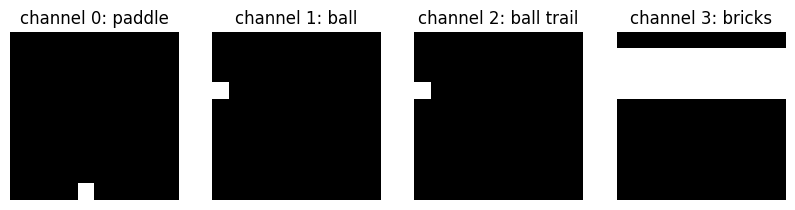

In [15]:
#visualizing observation channels
obs, info = env.reset()
fig, axes = plt.subplots(1, 4, figsize=(10, 3))
titles = ['channel 0: paddle', 'channel 1: ball', 'channel 2: ball trail', 'channel 3: bricks']

for i in range(4):
    axes[i].imshow(obs[:, :, i], cmap='gray')
    axes[i].set_title(titles[i])
    axes[i].axis('off')
plt.show()

**Distribution of rewards and episode length for the random policy over 100 episodes**

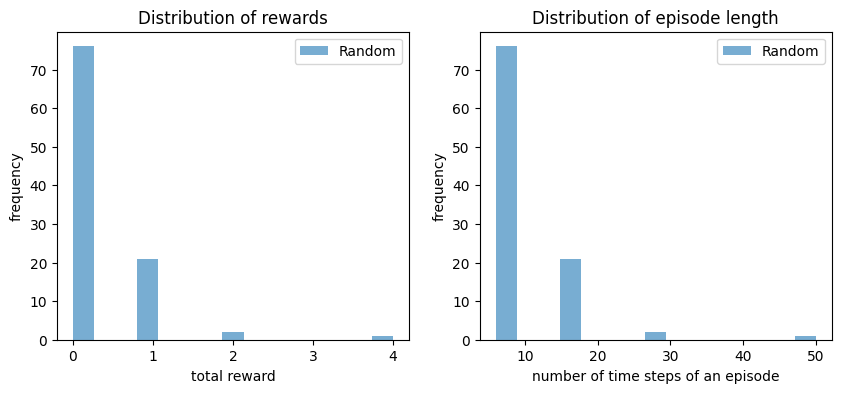

In [17]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.hist(random_rewards, bins=15, alpha=0.6, label='Random')
ax1.set_title('Distribution of rewards')
ax1.set_xlabel('total reward')
ax1.set_ylabel('frequency')
ax1.legend()

ax2.hist(random_steps, bins=15, alpha=0.6, label='Random')

ax2.set_title('Distribution of episode length')
ax2.set_xlabel('number of time steps of an episode')
ax2.set_ylabel('frequency')
ax2.legend()

plt.show()

In [ ]:

# 2. Distribution of rewards and episode length
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.hist(random_rewards, bins=15, alpha=0.6, label='Random')
ax1.hist(heuristic_rewards, bins=15, alpha=0.6, label='Heuristic')
ax1.set_title('Distribution des récompenses')
ax1.set_xlabel('Récompense totale')
ax1.set_ylabel('Fréquence')
ax1.legend()

ax2.hist(random_steps, bins=15, alpha=0.6, label='Random')
ax2.hist(heuristic_steps, bins=15, alpha=0.6, label='Heuristic')
ax2.set_title('Distribution de la durée des épisodes')
ax2.set_xlabel('Nombre de pas')
ax2.set_ylabel('Fréquence')
ax2.legend()

plt.show()

---

## Part 2: A Classical RL Method [8 marks]

Implement a reinforcement learning algorithm that does not use neural networks for function approximation.

### Requirements

- Choose an appropriate algorithm given your analysis of the state space
- Choose an appropriate state representation
- Justify your choices based on the environment properties you identified in Part 1

### Questions to Address

1. **State representation**: How do you represent the state? Why is this representation appropriate for your chosen algorithm?

2. **Algorithm description**: What algorithm did you implement? Write out the update rules.

3. **Hyperparameters**: What hyperparameters does your method have? How did you select their values?

4. **Learning curves**: Plot the return during training. Include error bars or confidence intervals if you run multiple seeds.

5. **Comparison to baselines**: How does your trained policy compare to the random and heuristic baselines?

---

## Part 3: A Deep RL Method [10 marks]

Implement a reinforcement learning algorithm that uses neural networks for function approximation.

### Requirements

- Choose an appropriate algorithm
- Design a neural network architecture suited to the observation space
- Apply techniques to stabilize training as needed

### Questions to Address

1. **State representation**: Do you use the raw observation or a transformed representation? How does this choice influence your network architecture?

2. **Algorithm description**: What algorithm did you implement? Describe the loss function and update procedure.

3. **Architecture**: What neural network architecture did you use? Justify your design choices.

4. **Learning curves**: Plot training progress. Compare different hyperparameter choices, if applicable.

5. **Comparison**: How does the deep RL method compare to your classical RL method from Part 2? Consider sample efficiency, final performance, and training stability.

---

## Part 4: Policy Interpretation [8 marks]

Analyze the behavior of your trained agents.

### Questions to Address

1. **Qualitative behavior**: Report a video of your trained agent playing. Describe its strategy in words. Does it behave similarly to the heuristic, or has it learned a different approach?

2. **State-action analysis**: For your best policy, visualize what actions it selects in different states.

3. **Failure cases**: Identify situations where the policy makes poor decisions. What do these cases have in common?

4. **Comparison across methods**: Do your classical and deep RL methods learn similar or different strategies? If not, why ?

---

## Part 5: Improving Performance [4 marks]

Investigate techniques to improve your agents' performance and training stability.

### Requirements

Choose **at least two** of the following directions:

- **Ablation study**: Remove or modify components of your algorithm and measure the impact.
- **Variance reduction**: Implement and compare techniques to reduce gradient variance.
- **Regularization**: Experiment with regularization techniques and analyze their effects.
- **Hyperparameter sensitivity**: Systematically vary hyperparameters and report their effects.
- **Exploration strategies**: Compare different exploration methods. [At least 2]

### Instructions for the report

For each investigation:
- State your hypothesis before running experiments
- Present results with appropriate visualizations
- Discuss whether results matched your expectations and explain any surprises
- Discuss the limitations and their probable solutions of your proposed approach.

---

## Part 6: Generalization to Other Environments [5 marks]

Test whether your methods transfer to other MinAtar games: Asterix, Freeway, Seaquest, and Space Invaders.

### Questions to Address

1. **Direct transfer**: Apply your best Breakout agent (without retraining) to another game. Does it perform better than random? Why or why not?

2. **Retraining**: Train your deep RL method on at least one other MinAtar game. Does it achieve similar performance relative to the random baseline? If performance differs, explain why.

3. **Architecture/hyperparameter transfer**: Can you use the same configuration across games, or do different games require different configurations?

4. **Game difficulty**: Which games are easier or harder to learn? Relate this to environment properties.


---

## Summary

Conclude your notebook with a brief summary of:

- Your main findings across all parts
- What worked well and what did not
- What you would try next if you had more time

Make one paragraph answering these three points for each part of the assignment.